Importing headers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

reading csv file

In [ ]:
df = pd.read_csv("Machine Learning/kidney_disease.csv")
print(df)

      id   age    bp     sg   al   su     rbc        pc         pcc  \
0      0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent   
1      1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent   
2      2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent   
3      3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present   
4      4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent   
..   ...   ...   ...    ...  ...  ...     ...       ...         ...   
395  395  55.0  80.0  1.020  0.0  0.0  normal    normal  notpresent   
396  396  42.0  70.0  1.025  0.0  0.0  normal    normal  notpresent   
397  397  12.0  80.0  1.020  0.0  0.0  normal    normal  notpresent   
398  398  17.0  60.0  1.025  0.0  0.0  normal    normal  notpresent   
399  399  58.0  80.0  1.025  0.0  0.0  normal    normal  notpresent   

             ba  ...  pcv    wc   rc  htn   dm  cad appet   pe  ane  \
0    notpresent  ...   44  7800  5.2  yes  yes   no  good   no   no   
1    

In [4]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [68]:
#basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [69]:
# Describing the data set
print(df.describe())

               id         age          bp          sg          al          su  \
count  400.000000  391.000000  388.000000  353.000000  354.000000  351.000000   
mean   199.500000   51.483376   76.469072    1.017408    1.016949    0.450142   
std    115.614301   17.169714   13.683637    0.005717    1.352679    1.099191   
min      0.000000    2.000000   50.000000    1.005000    0.000000    0.000000   
25%     99.750000   42.000000   70.000000    1.010000    0.000000    0.000000   
50%    199.500000   55.000000   80.000000    1.020000    0.000000    0.000000   
75%    299.250000   64.500000   80.000000    1.020000    2.000000    0.000000   
max    399.000000   90.000000  180.000000    1.025000    5.000000    5.000000   

              bgr          bu          sc         sod         pot        hemo  
count  356.000000  381.000000  383.000000  313.000000  312.000000  348.000000  
mean   148.036517   57.425722    3.072454  137.528754    4.627244   12.526437  
std     79.281714   50.503006 

In [6]:
print(df.duplicated().sum())

0


In [5]:
# Performing the necessary data pre-processing technique (missing values, normalization,etc)
# Checking for missing values
print(df.isnull().sum())

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [71]:
df.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

In [6]:
df['wc'] = df['wc'].str.strip()
df['wc'] = df['wc'].replace('?', np.nan)
df['wc'] = df['wc'].astype(float)
df['pcv'] = df['pcv'].str.strip()
df['pcv'] = df['pcv'].replace('?', np.nan)
df['pcv'] = df['pcv'].astype(float)
df['rc'] = df['rc'].str.strip()
df['rc'] = df['rc'].replace('?', np.nan)
df['rc'] = df['rc'].astype(float)

Filling null values with mean

In [7]:
df['age'].fillna(df['age'].mean(), inplace=True)
df['bp'].fillna(df['bp'].mean(), inplace=True)
df['sg'].fillna(df['sg'].mean(), inplace=True)
df['al'].fillna(df['al'].mean(), inplace=True)
df['su'].fillna(df['su'].mean(), inplace=True)
df['bgr'].fillna(df['bgr'].mean(), inplace=True)
df['bu'].fillna(df['bu'].mean(), inplace=True)
df['sc'].fillna(df['sc'].mean(), inplace=True)
df['sod'].fillna(df['sod'].mean(), inplace=True)
df['pot'].fillna(df['pot'].mean(), inplace=True)
df['hemo'].fillna(df['hemo'].mean(), inplace=True)
df['pcv'].fillna(df['pcv'].mean(), inplace=True)
df['wc'].fillna(df['wc'].mean(), inplace=True)
df['rc'].fillna(df['rc'].mean(), inplace=True)

In [8]:
print(df.isnull().sum())

id                  0
age                 0
bp                  0
sg                  0
al                  0
su                  0
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                 0
bu                  0
sc                  0
sod                 0
pot                 0
hemo                0
pcv                 0
wc                  0
rc                  0
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


Filling catagorical colums with mode

In [9]:
df = df.fillna(df.mode().iloc[0])

In [10]:
print(df.isnull().sum())

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


Checking for outliers

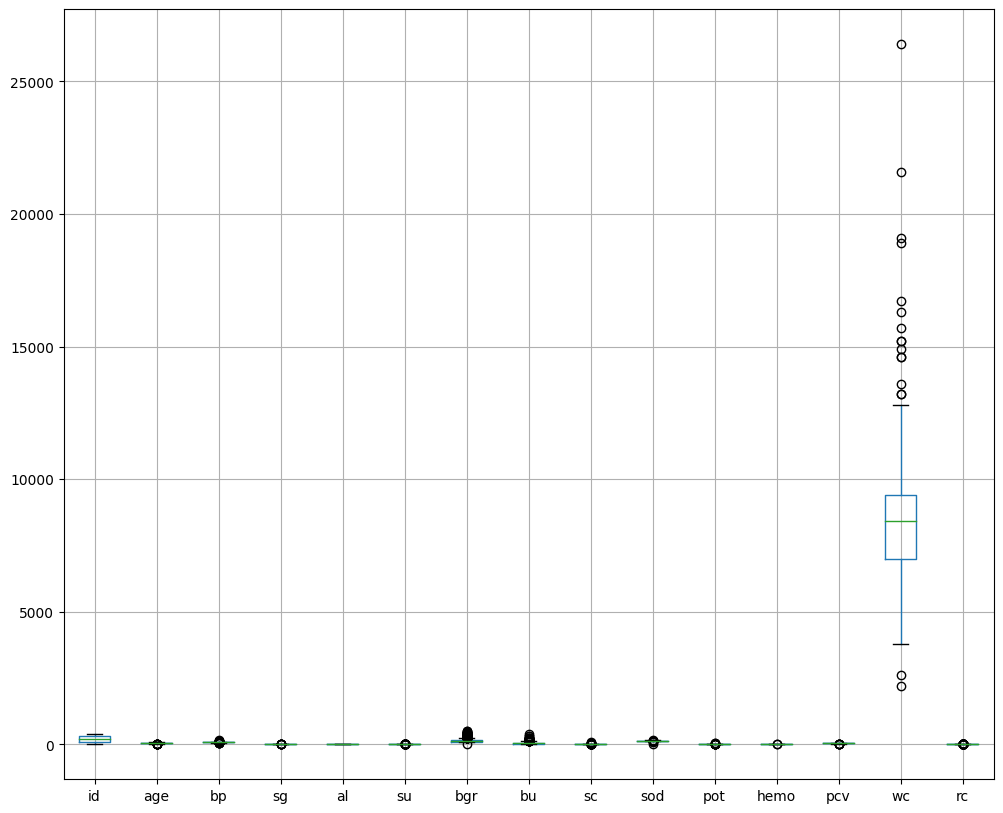

In [77]:
df.boxplot(figsize=(12,10))
plt.show()

In [11]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
#print(((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))))
print(((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum())

age               10
al                 0
ane                0
appet              0
ba                 0
bgr               53
bp                36
bu                41
cad                0
classification     0
dm                 0
hemo               2
htn                0
id                 0
pc                 0
pcc                0
pcv                6
pe                 0
pot               14
rbc                0
rc                75
sc                44
sg                 7
sod               18
su                48
wc                17
dtype: int64


Removing Outliers

age               0
al                0
ane               0
appet             0
ba                0
bgr               0
bp                0
bu                0
cad               0
classification    0
dm                0
hemo              0
htn               0
id                0
pc                0
pcc               0
pcv               0
pe                0
pot               0
rbc               0
rc                0
sc                0
sg                0
sod               0
su                0
wc                0
dtype: int64


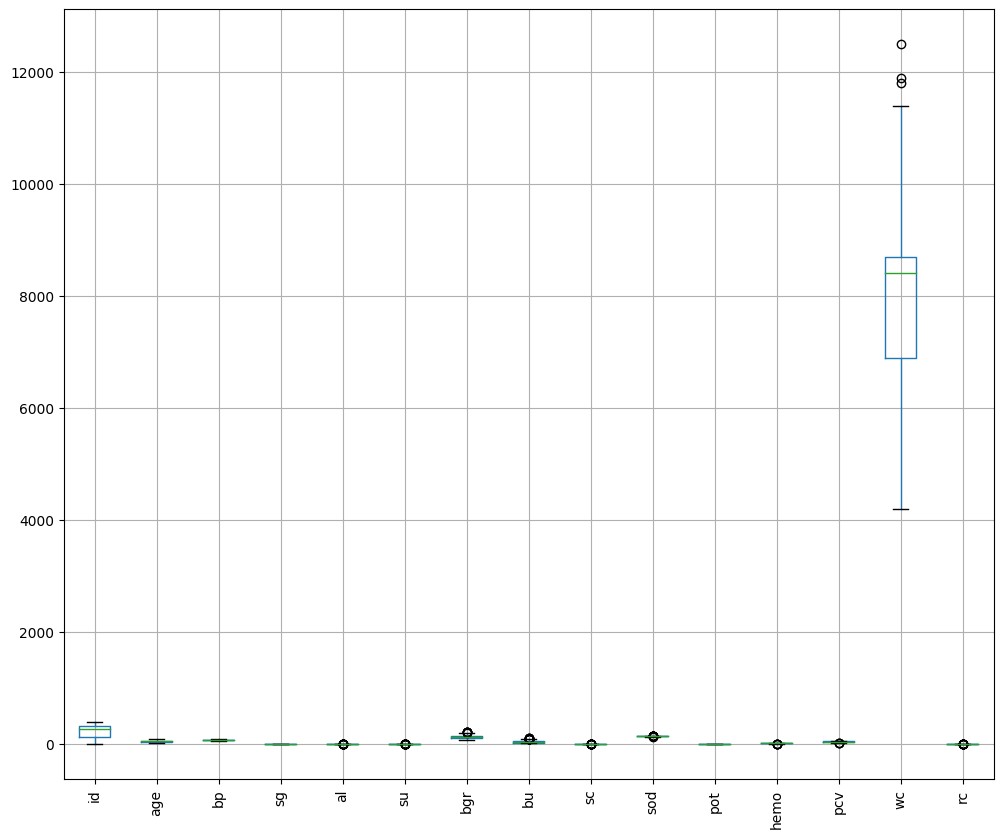

In [12]:
df1 = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(((df1 < (Q1 - 1.5 * IQR)) | (df1 > (Q3 + 1.5 * IQR))).sum())
df1.boxplot(figsize=(12,10))
plt.tick_params(axis='x', labelrotation = 90)
plt.show()

In [80]:
print(df1.isna().sum())

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


Convert the categorical columns to numerical columns

In [13]:
# Convert the categorical columns to numerical columns
df1['classification'] = df1['classification'].map({'ckd': 1, 'notckd': 0})
df1['rbc'] = df1['rbc'].map({'normal': 1, 'abnormal': 0})
df1['pc'] = df1['pc'].map({'normal': 1, 'abnormal': 0})
df1['pcc'] = df1['pcc'].map({'present': 1, 'notpresent': 0})
df1['ba'] = df1['ba'].map({'present': 1, 'notpresent': 0})
df1['htn'] = df1['htn'].map({'yes': 1, 'no': 0})
df1['dm'] = df1['dm'].map({'yes': 1, 'no': 0})
df1['cad'] = df1['cad'].map({'yes': 1, 'no': 0})
df1['appet'] = df1['appet'].map({'good': 1, 'poor': 0})
df1['pe'] = df1['pe'].map({'yes': 1, 'no': 0})
df1['ane'] = df1['ane'].map({'yes': 1, 'no': 0})

In [14]:
print(df1.isna().sum())

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                3
cad               2
appet             0
pe                0
ane               0
classification    1
dtype: int64


In [15]:
df1 = df1.fillna(df1.mode().iloc[0])

In [16]:
print(df1.isna().sum())

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


In [85]:
df1.dtypes

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                 int64
pc                  int64
pcc                 int64
ba                  int64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn                 int64
dm                float64
cad               float64
appet               int64
pe                  int64
ane                 int64
classification    float64
dtype: object

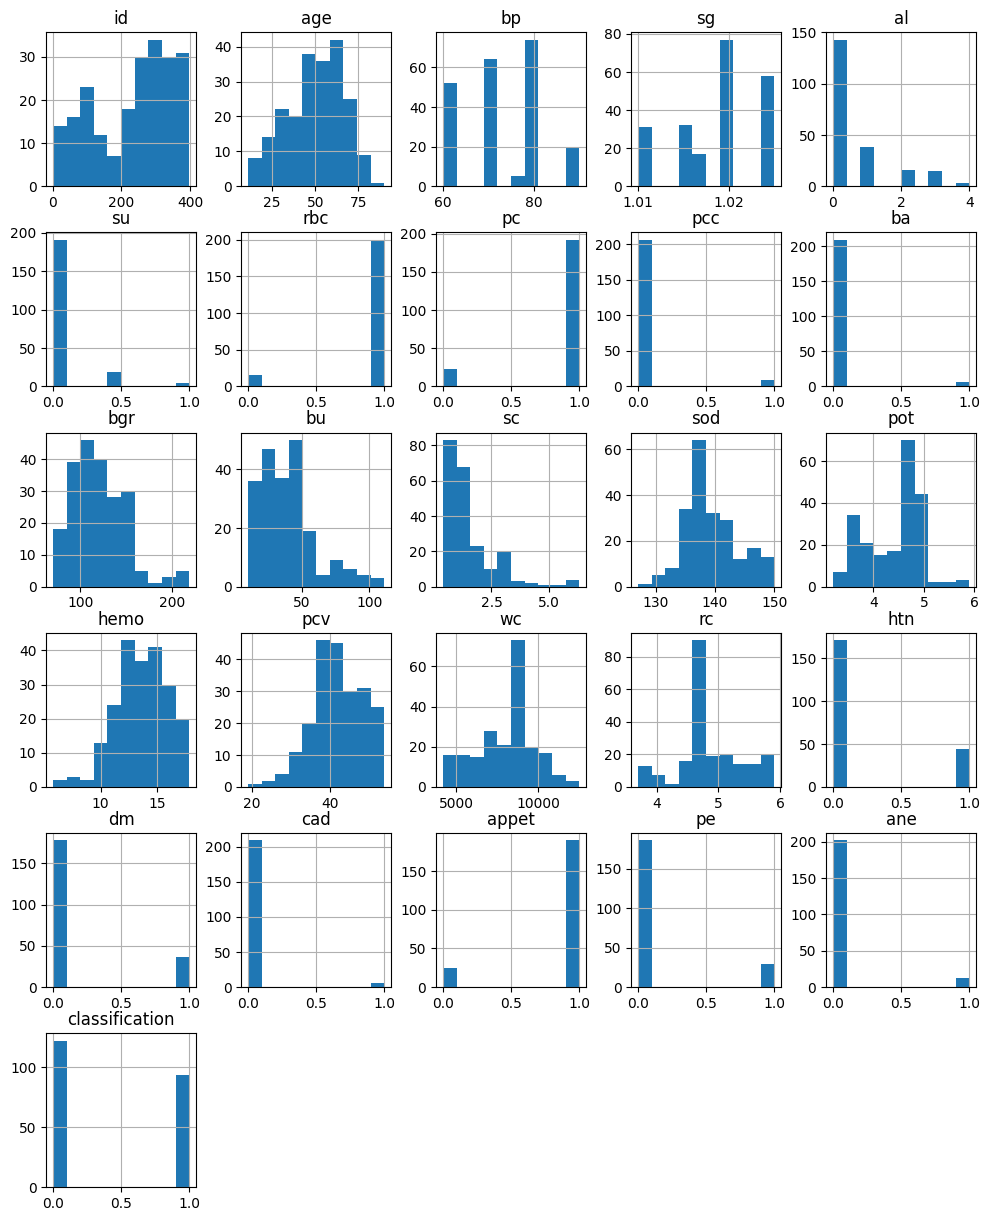

In [86]:
# Histograms of all features
df1.hist(figsize=(12,15))
plt.show()

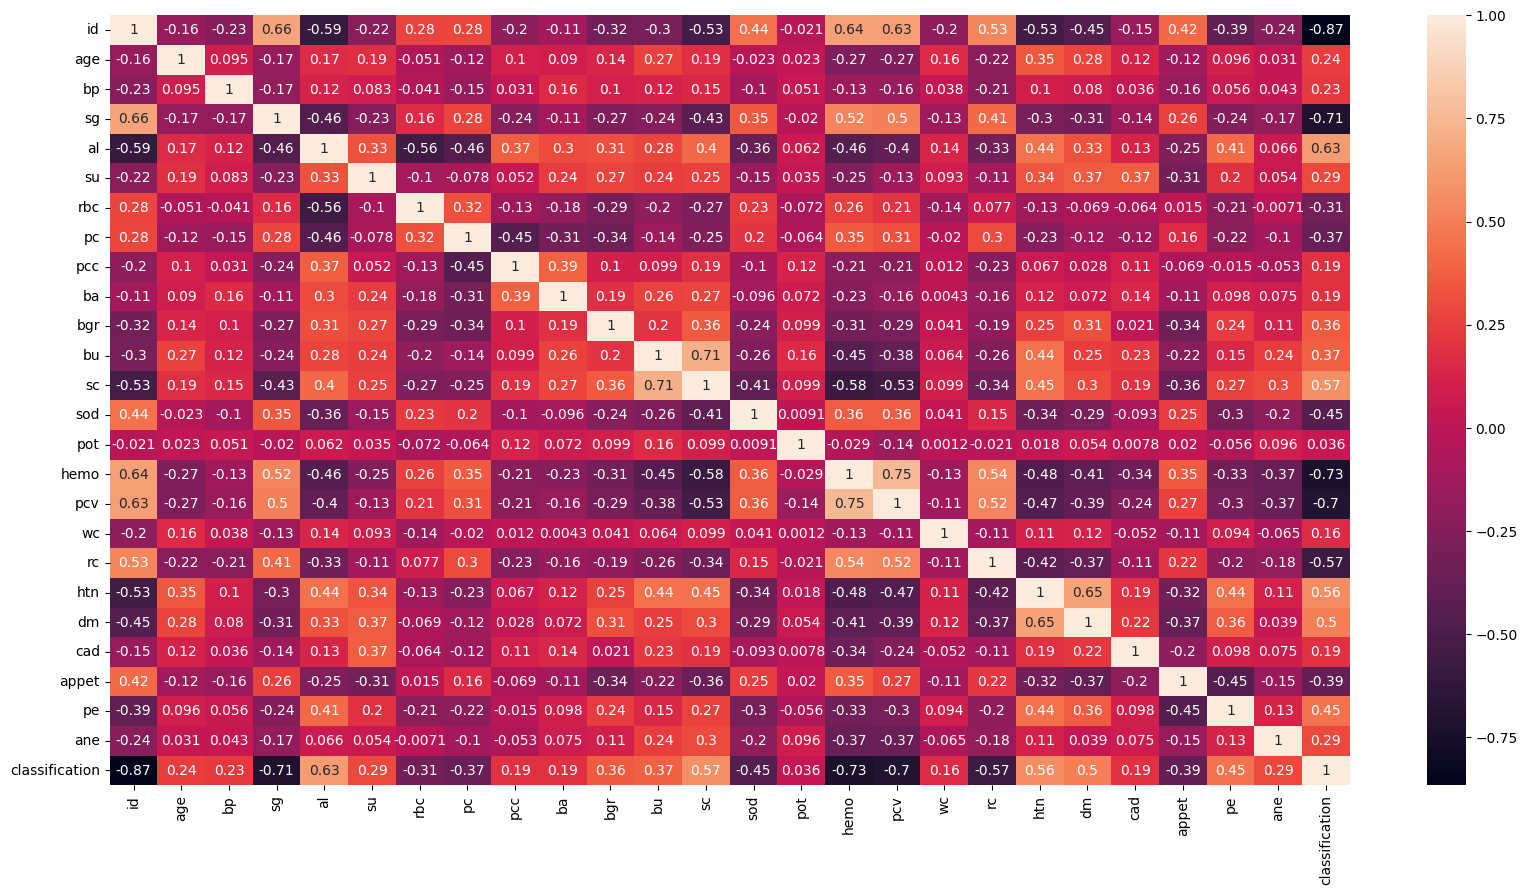

In [17]:
plt.figure(figsize=(20,10))
sns.heatmap(df1.corr(),annot=True)
plt.show()

In [19]:
x = df1.drop('classification', axis=1) # Independent features
y = df1['classification'] # Dependent feature
print('Independent features:', x.columns)
print('Dependent feature:', y.name)

Independent features: Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane'],
      dtype='object')
Dependent feature: classification


In [20]:
# Dropping the features that are not numeric
df1 = df1.select_dtypes(include=np.number)
print(df1.dtypes)

id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                 int64
pc                  int64
pcc                 int64
ba                  int64
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv               float64
wc                float64
rc                float64
htn                 int64
dm                float64
cad               float64
appet               int64
pe                  int64
ane                 int64
classification    float64
dtype: object


In [21]:
# Normalizing the data using Min-Max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df1)
X_scaled = pd.DataFrame(X_scaled, columns=df1.columns)
print(X_scaled)

           id       age        bp        sg        al        su  rbc   pc  \
0    0.000000  0.468354  0.666667  0.666667  0.250000  0.000000  1.0  1.0   
1    0.010050  0.506329  0.666667  0.000000  0.500000  0.000000  1.0  1.0   
2    0.012563  0.620253  1.000000  0.333333  0.750000  0.000000  1.0  1.0   
3    0.032663  0.721519  0.333333  0.493862  0.254237  0.450142  1.0  1.0   
4    0.040201  0.455696  0.333333  0.333333  0.500000  0.000000  1.0  1.0   
..        ...       ...       ...       ...       ...       ...  ...  ...   
210  0.987437  0.405063  0.000000  1.000000  0.000000  0.000000  1.0  1.0   
211  0.989950  0.493671  0.666667  0.666667  0.000000  0.000000  1.0  1.0   
212  0.992462  0.556962  0.666667  0.666667  0.000000  0.000000  1.0  1.0   
213  0.997487  0.012658  0.666667  0.666667  0.000000  0.000000  1.0  1.0   
214  1.000000  0.075949  0.000000  1.000000  0.000000  0.000000  1.0  1.0   

     pcc   ba  ...       pcv        wc        rc  htn   dm  cad  appet   pe

In [22]:
corr = X_scaled.corr()
print(corr['classification'])

id               -0.866250
age               0.243637
bp                0.227950
sg               -0.707618
al                0.628075
su                0.286729
rbc              -0.313667
pc               -0.366042
pcc               0.192524
ba                0.194062
bgr               0.357467
bu                0.374763
sc                0.567500
sod              -0.450869
pot               0.035900
hemo             -0.734356
pcv              -0.695032
wc                0.164368
rc               -0.569932
htn               0.557718
dm                0.497319
cad               0.194062
appet            -0.386176
pe                0.452252
ane               0.290559
classification    1.000000
Name: classification, dtype: float64


In [23]:
x = X_scaled.drop('classification', axis=1) # Independent features
y = X_scaled['classification'] # Dependent feature
print('Independent features:', x.columns)
print('Dependent feature:', y.name)

Independent features: Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane'],
      dtype='object')
Dependent feature: classification


checking for vif values

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif['feature'] = x.columns
vif['VIF'] = [variance_inflation_factor(x, i) for i in range(x.shape[1])]
print(vif)

   feature        VIF
0       id  18.894468
1      age   8.234450
2       bp   3.215822
3       sg   8.745490
4       al   3.401902
5       su   1.734375
6      rbc  19.246666
7       pc  15.027908
8      pcc   1.731047
9       ba   1.450765
10     bgr   5.191679
11      bu   7.898690
12      sc   5.636432
13     sod  11.891442
14     pot   6.207991
15    hemo  41.730756
16     pcv  35.934604
17      wc   6.181184
18      rc  11.338879
19     htn   3.485502
20      dm   2.577207
21     cad   1.346028
22   appet  11.966095
23      pe   1.823093
24     ane   1.368793


Droping feartures with greater than 10 vif value

In [25]:
X_reduced = X_scaled.drop(['id','rbc','pc','sod','hemo','pcv','rc','appet'], axis=1)
X_reduced

,age,bp,sg,al,su,pcc,ba,bgr,bu,sc,pot,wc,htn,dm,cad,pe,ane,classification
0,0.468354,0.666667,0.666667,0.250000,0.000000,0.0,0.0,0.342282,0.257426,0.135593,0.528609,0.433735,1.0,1.0,0.0,0.0,0.0,1.0
1,0.506329,0.666667,0.000000,0.500000,0.000000,0.0,0.0,0.241611,0.158416,0.169492,0.528609,0.373494,0.0,0.0,0.0,0.0,0.0,1.0
2,0.620253,1.000000,0.333333,0.750000,0.000000,0.0,0.0,0.026846,0.148515,0.118644,0.000000,0.433735,1.0,1.0,0.0,1.0,0.0,1.0
3,0.721519,0.333333,0.493862,0.254237,0.450142,0.0,0.0,0.187919,0.752475,0.711864,0.074074,0.506762,1.0,1.0,1.0,1.0,0.0,1.0
4,0.455696,0.333333,0.333333,0.500000,0.000000,0.0,0.0,0.194631,0.356436,0.305085,0.333333,0.506762,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,0.405063,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.315436,0.346535,0.050847,0.444444,0.385542,0.0,0.0,0.0,0.0,0.0,0.0
211,0.493671,0.666667,0.666667,0.000000,0.000000,0.0,0.0,0.449664,0.356436,0.067797,0.666667,0.638554,0.0,0.0,0.0,0.0,0.0,0.0
212,0.556962,0.666667,0.666667,0.000000,0.000000,0.0,0.0,0.469799,0.386139,0.016949,0.629630,0.301205,0.0,0.0,0.0,0.0,0.0,0.0
213,0.012658,0.666667,0.666667,0.000000,0.000000,0.0,0.0,0.201342,0.158416,0.033898,0.444444,0.289157,0.0,0.0,0.0,0.0,0.0,0.0


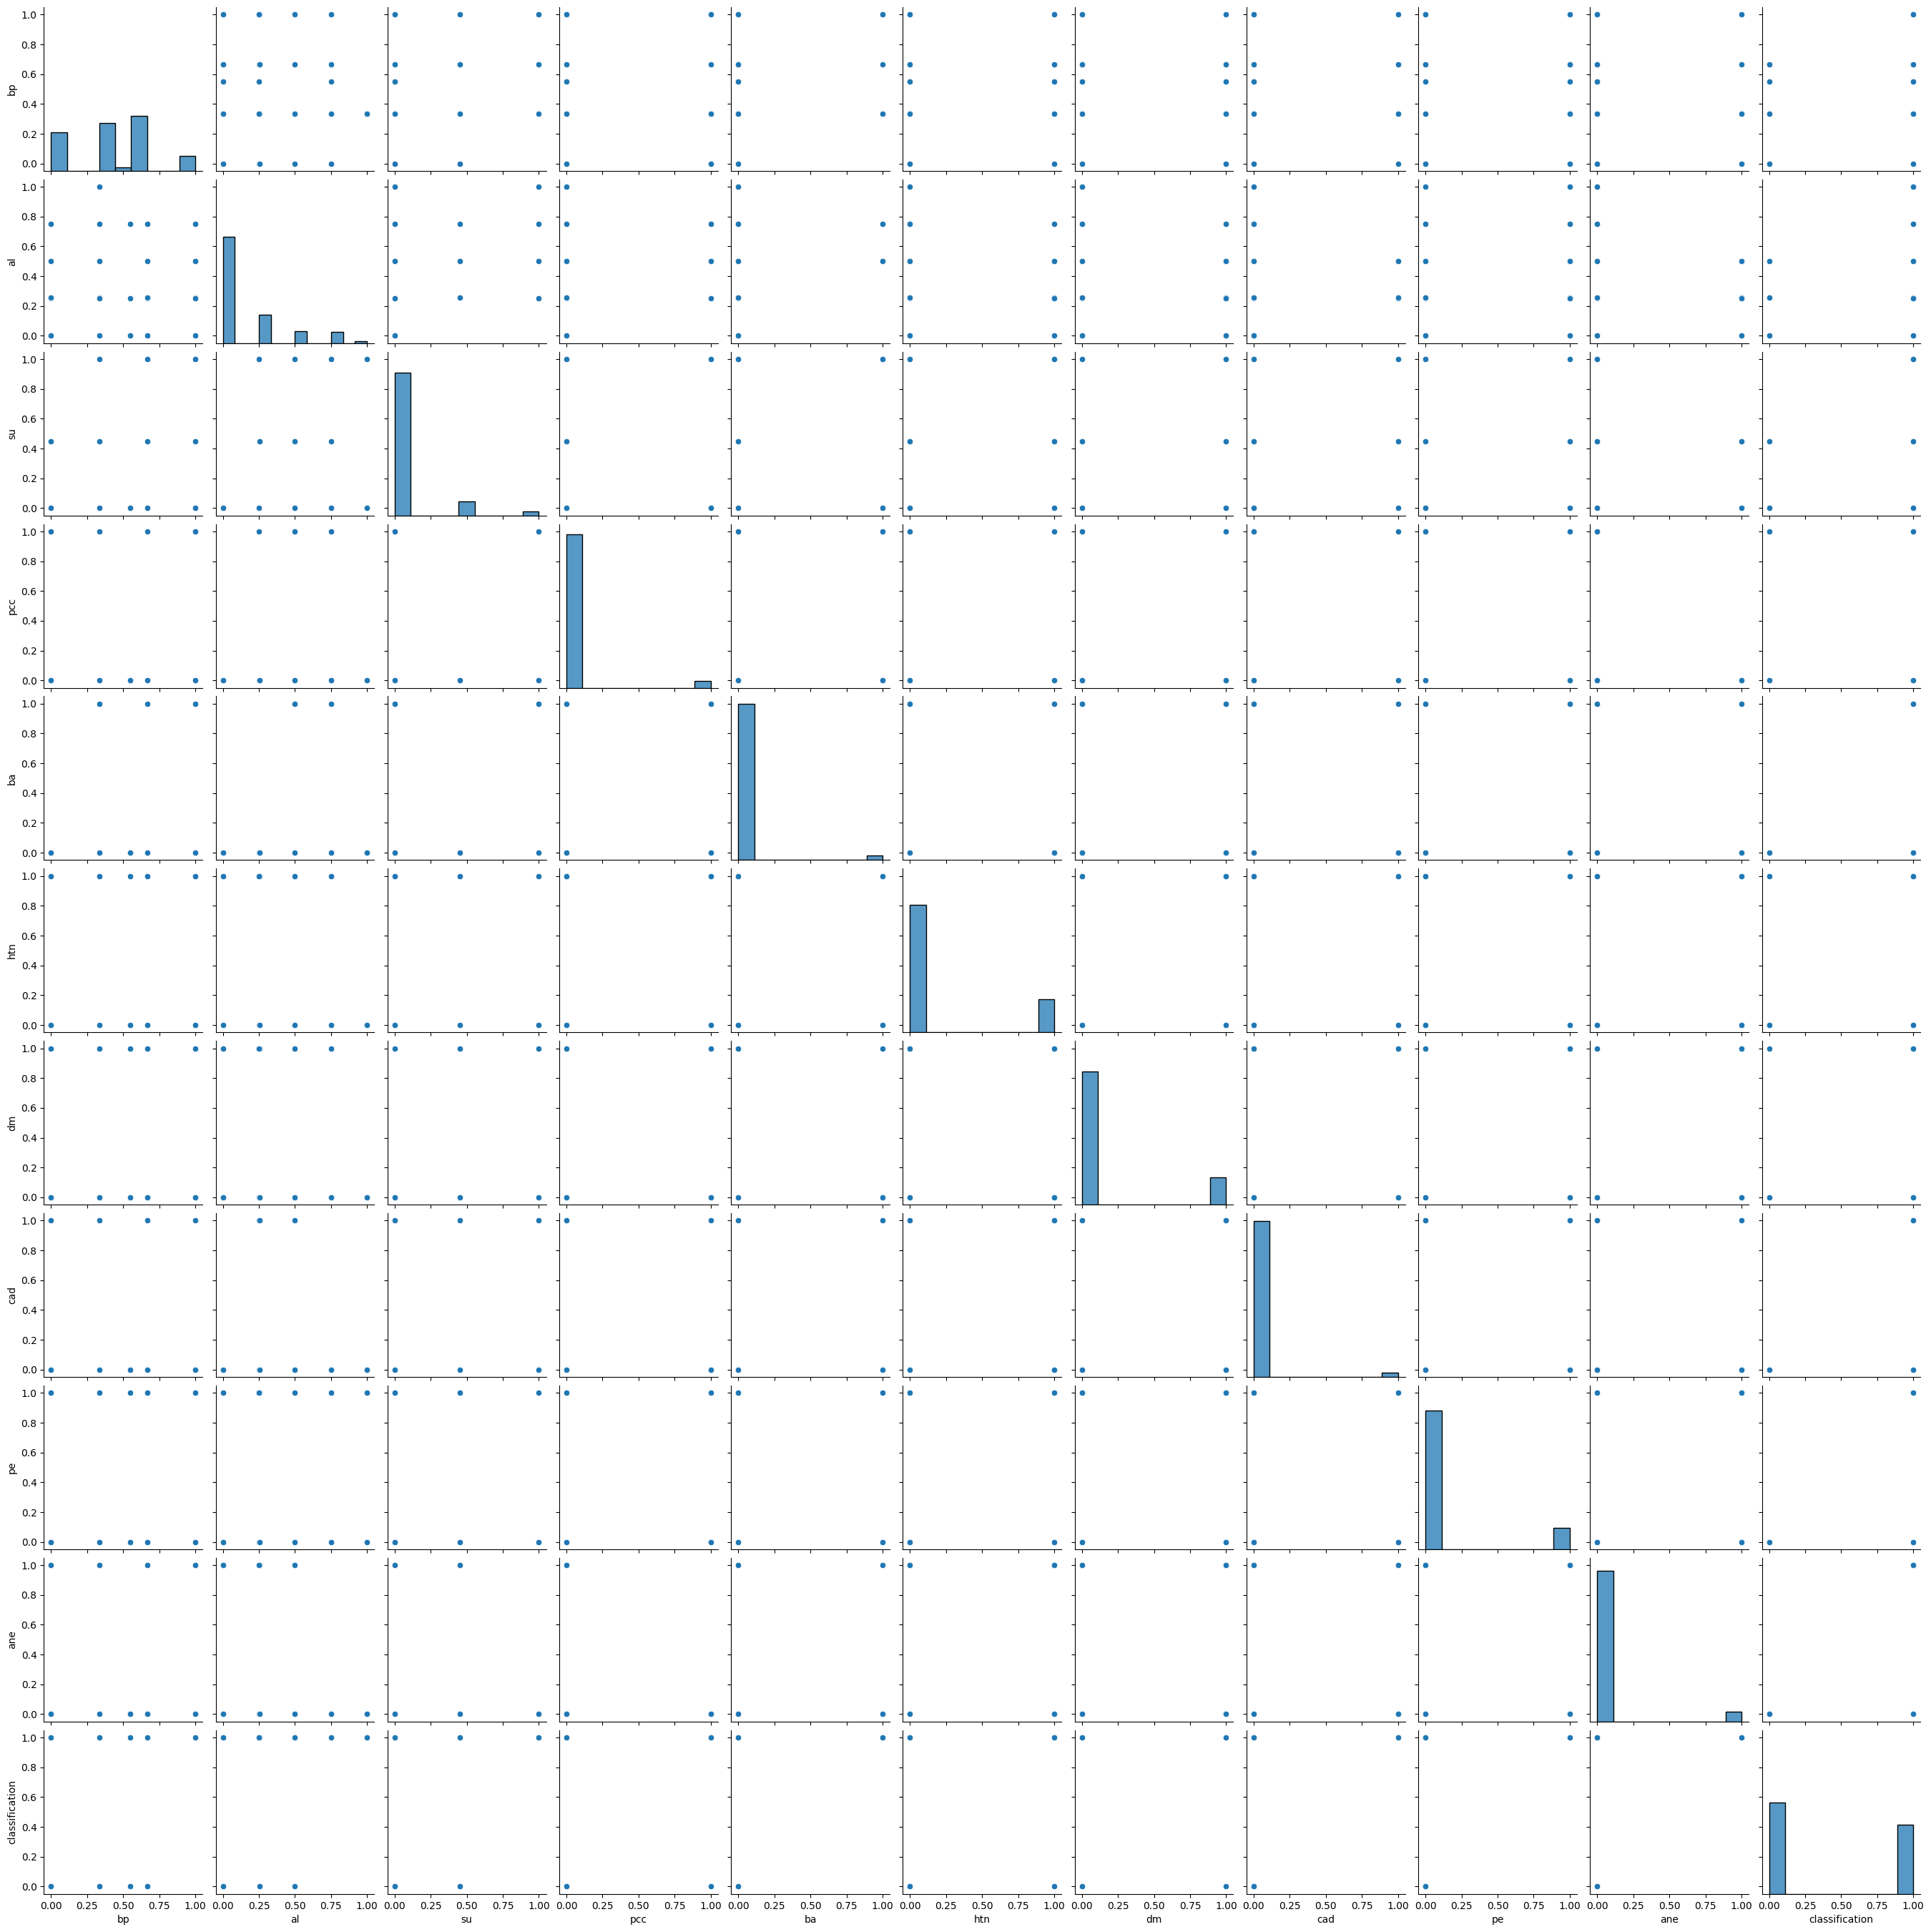

In [34]:
sns.pairplot(X_reduced)
plt.show()

In [26]:
corr = X_reduced.corr()
print(corr['classification'])

age               0.243637
bp                0.227950
sg               -0.707618
al                0.628075
su                0.286729
pcc               0.192524
ba                0.194062
bgr               0.357467
bu                0.374763
sc                0.567500
pot               0.035900
wc                0.164368
htn               0.557718
dm                0.497319
cad               0.194062
pe                0.452252
ane               0.290559
classification    1.000000
Name: classification, dtype: float64


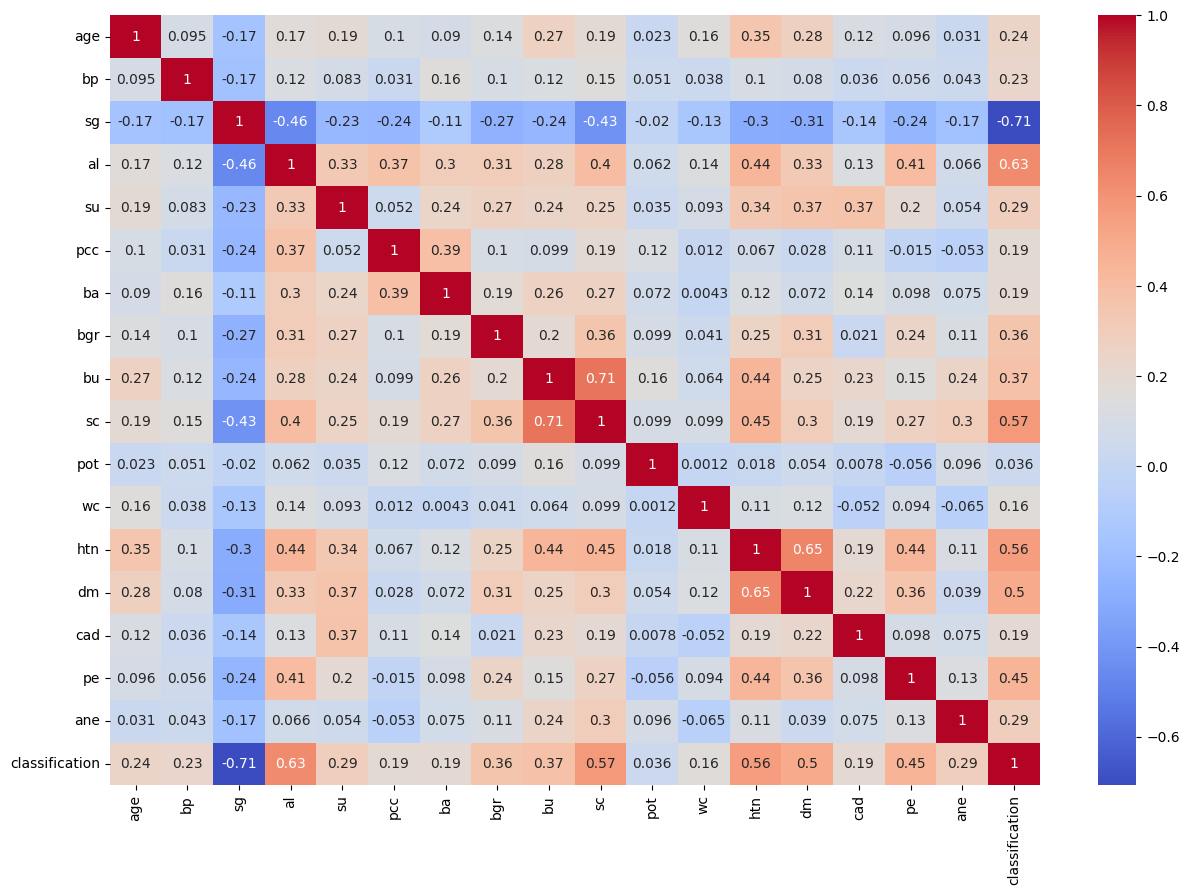

In [28]:
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
x = X_reduced.drop('classification', axis=1)
y = X_reduced['classification']

spliting the data for training and testing

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

# MLPClassifier

In [ ]:
from sklearn.neural_network import MLPClassifier

# Create the MLPClassifier object
clf = MLPClassifier(hidden_layer_sizes=(10,), max_iter=50)  
# Convert the labels to integers
y_train = y_train.astype(int)
y_test = y_test.astype(int)
# Fit the model to the training data
clf.fit(x_train, y_train)
# Evaluate the model on the test data
score = clf.score(x_test, y_test)
print('Score: {0:.2f}%'.format(score * 100))

Score: 77.78%


In [94]:
# Define the parameters to tune
param_grid = {
    'hidden_layer_sizes': [(150,100,50), (120,80,40), (100,50,30)],
    'max_iter': [50, 100, 150],
    'activation': ['tanh','sigmoid', 'relu'],
    'solver': ['sgd', 'adam'],
    'alpha': [0.0001, 0.05],
    'learning_rate': ['constant','adaptive'],
}
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(clf, param_grid, n_jobs= -1, cv=5)
grid.fit(x_train, y_train)
print('Best parameters:',grid.best_params_)

Best parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (150, 100, 50), 'learning_rate': 'constant', 'max_iter': 150, 'solver': 'adam'}


In [96]:
from sklearn.metrics import accuracy_score  
grid_predictions = grid.predict(x_test) 
print('Accuracy: {:.2f}'.format(accuracy_score(y_test, grid_predictions)))

Accuracy: 0.98


In [97]:
# Print the Confusion Matrix and slice it into four pieces
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, grid_predictions)
print('Confusion matrix\n\n', cm)

Confusion matrix

 [[31  0]
 [ 1 22]]


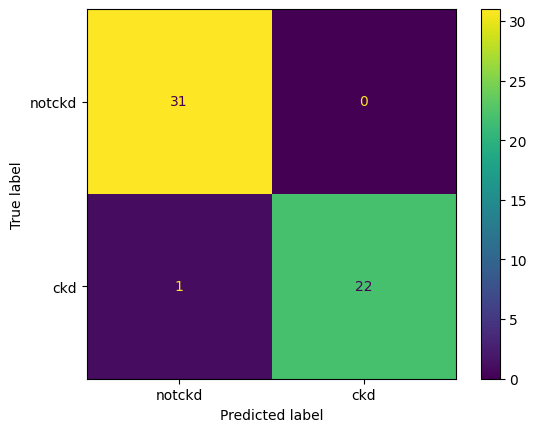

In [101]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Creating the Confusion Matrix using ConfusionMatrixDisplay class
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,grid_predictions), display_labels=['notckd', 'ckd'])
cm_display.plot()
plt.show()

In [99]:
# Predict the probabilities of the test data
y_proba = grid.predict_proba(x_test)
# Calculate the ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
# Calculate the AUC
auc = roc_auc_score(y_test, y_proba[:, 1])

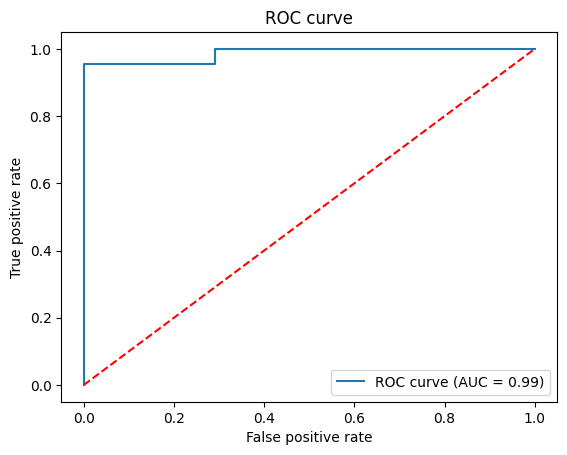

In [100]:
# Plot the ROC curve
plt.plot(fpr, tpr, label="ROC curve (AUC = {0:.2f})".format(auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

# SVM (support vector machine)

In [102]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Create the SVM model
clfsvc = SVC(C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=1, decision_function_shape='ovr')
# Fit the model to the training data
clfsvc.fit(x_train, y_train)

# Make predictions on the test data
y_pred = clfsvc.predict(x_test)

# Evaluate the model
print(clfsvc.score(x_test, y_test))
# Evaluate the model on the test data
score = clfsvc.score(x_test, y_test)

# Print the score
print('Score: {0:.2f}%'.format(score * 100))

0.3888888888888889
Score: 38.89%


In [108]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

clfsvc = SVC(random_state=42) 

param_grid = {
    'C': [1, 25,50,75,100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
}
grid_searchsvm = GridSearchCV(SVC(probability=True,random_state=42), param_grid, cv=5, scoring='accuracy') 
grid_searchsvm.fit(x_train, y_train)
print('Best parameters:', grid_searchsvm.best_params_)
print(grid_searchsvm.score(x_test, y_test)) 

Best parameters: {'C': 25, 'gamma': 'scale', 'kernel': 'rbf'}
0.9814814814814815


In [109]:
# Predict the class labels of the test data
grid_predictions = grid_searchsvm.predict(x_test) 
print('Accuracy: {:.2f}'.format(accuracy_score(y_test, grid_predictions)))

Accuracy: 0.98


In [113]:

# Print the classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        31
           1       1.00      0.96      0.98        23

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



In [114]:
# Print the Confusion Matrix and slice it into four pieces
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, grid_predictions)
print('Confusion matrix\n\n', cm)

Confusion matrix

 [[31  0]
 [ 1 22]]


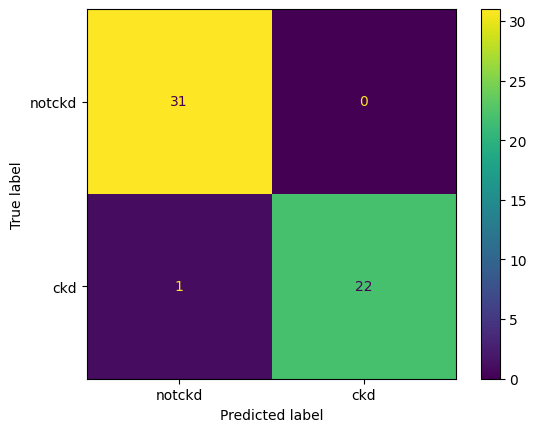

In [115]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Creating the Confusion Matrix using ConfusionMatrixDisplay class
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,grid_predictions), display_labels=['notckd', 'ckd'])
cm_display.plot()
plt.show()

In [61]:
# Predict the probabilities of the test data
y_proba = grid_searchsvm.predict_proba(x_test)
# Calculate the ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
# Calculate the AUC
auc = roc_auc_score(y_test, y_proba[:, 1])

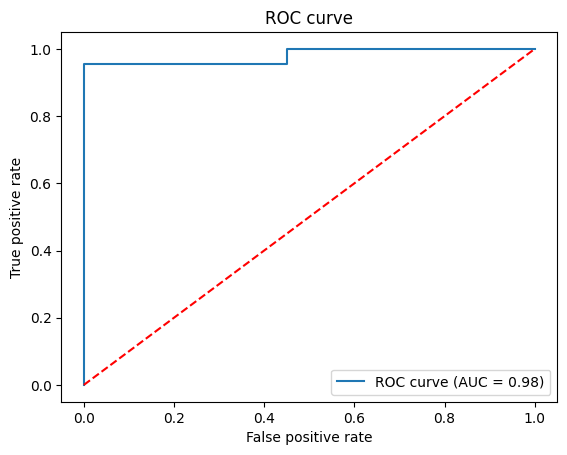

In [62]:
# Plot the ROC curve
plt.plot(fpr, tpr, label="ROC curve (AUC = {0:.2f})".format(auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()

# KNN (k-nearest neighbors)

In [129]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Create a KNN classifier
knn = KNeighborsClassifier(n_neighbors=5, p=2,metric='minkowski',weights='uniform', algorithm='auto', leaf_size=30,   metric_params=None, n_jobs=None)
k_values = [1, 3, 5, 7, 9]
# Iterate over different values of k
for k in k_values:

    # Train the classifier on the training set
    knn.fit(x_train, y_train)
    # Evaluate the classifier on the test set
    score = knn.score(x_test, y_test)
    # Record the performance of the classifier
    print('k = {}, score = {:.2f}'.format(k, score))

# Use cross validation to find the best value of k
scores = cross_val_score(knn, x_train, y_train, cv=5)
# Print the best value of k
print('Best k = {}, score = {:.2f}'.format(scores.argmax()+1, scores.max()))

# Train the classifier on the entire dataset with the best value of k
knn.fit(x_train, y_train)
# Make predictions on the test data
y_pred1 = knn.predict(x_test)
# Evaluate the classifier on the test set
score = knn.score(x_test, y_test)

# Print the accuracy of the classifier
print('Accuracy = {:.2f}'.format(score))


k = 1, score = 0.94
k = 3, score = 0.94
k = 5, score = 0.94
k = 7, score = 0.94
k = 9, score = 0.94
Best k = 3, score = 1.00
Accuracy = 0.94


In [130]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Create the KNN classifier
clf = KNeighborsClassifier()

# Define the hyperparameters to tune
params = {'n_neighbors': [1, 3, 5, 7, 9],
          'metric': ['euclidean', 'manhattan', 'mahalanobis'],
          'weights': ['uniform', 'distance']}

# Create the grid search object
grid_search = GridSearchCV(clf, params, cv=5)

# Fit the grid search object to the data
grid_search.fit(x_train, y_train)

# Print the best hyperparameters
print(grid_search.best_params_)
# Print the best accuracy
print(grid_search.best_score_)

{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
0.9441287878787878


In [131]:
# Print the Confusion Matrix and slice it into four pieces
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred1)
print('Confusion matrix\n\n', cm)

Confusion matrix

 [[31  0]
 [ 3 20]]


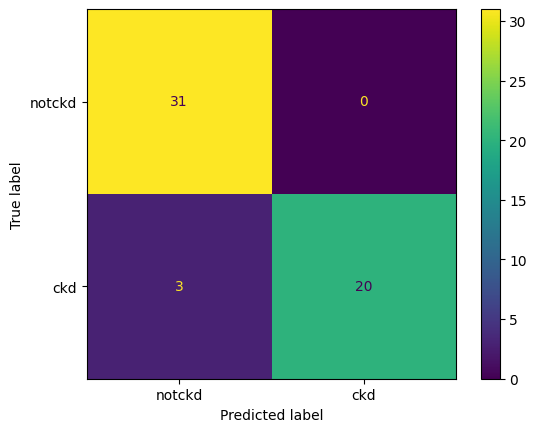

In [132]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Creating the Confusion Matrix using ConfusionMatrixDisplay class
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_pred1), display_labels=['notckd', 'ckd'])
cm_display.plot()
plt.show()

In [133]:
# Predict the probabilities of the test data
y_proba = knn.predict_proba(x_test)
# Calculate the ROC curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
# Calculate the AUC
auc = roc_auc_score(y_test, y_proba[:, 1])

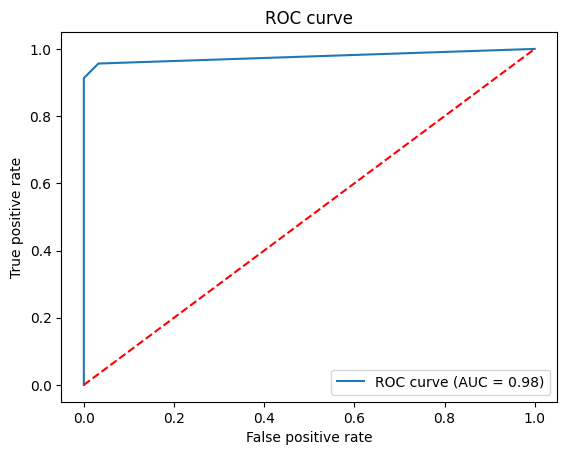

In [134]:
# Plot the ROC curve
plt.plot(fpr, tpr, label="ROC curve (AUC = {0:.2f})".format(auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()
plt.show()